# 量子振幅増幅・振幅推定とグローバー探索

このチュートリアルでは、量子状態の振幅を操作するという共通の基本原理を持つアルゴリズムを紹介します。前半では振幅増幅(QAA)を、後半では振幅推定(QAE)を扱います。

---

## パート I: 量子振幅増幅とグローバー探索

量子振幅増幅は、重ね合わせ状態の中の特定の状態の振幅を増幅させるアルゴリズムです。
これは、グローバーのアルゴリズムの設計の核となる概念です。

以下の図は、このアルゴリズムが量子状態に対してどのように機能するかを示しています。

<img width="30%" src="https://upload.wikimedia.org/wikipedia/commons/1/16/Grovers_algorithm_geometry.png">

参考: https://en.wikipedia.org/wiki/Grover%27s_algorithm

まず、上記の図に出てくる記号を説明します。

+ $\lvert s\rangle$ を任意の初期状態とします。
例えば、$\lvert s\rangle$ は $n$個の量子ビット上のすべての $2^n$ 個の状態の一様な重ね合わせとすることができます。このような初期状態はグローバーのアルゴリズムでよく使われます。

$$
\lvert s \rangle = \otimes^n  H  \lvert 0\rangle =\frac{1}{\sqrt{2^n}}\sum_{x}\lvert x\rangle
$$

見つけたい状態(マークされた状態)を $\lvert \omega\rangle$ とし、$\lvert s\rangle$ に直交する成分を $\lvert s'\rangle$ とします。

### 1.2. QAAの概要

アルゴリズムの概要は以下の通りです。

1. $U_{\omega}$ を使って $\lvert s\rangle$ を $\lvert s' \rangle$ を軸として反転させる。数学的には、$U_{\omega}$ は一様な重ね合わせ $\lvert s\rangle$ の中の $\lvert \omega\rangle$ の符号を反転させます。

2. $U_s$ を使って $U_{\omega}\lvert s\rangle$ を $\lvert s\rangle$ を軸として反転させる。

以上の過程を詳しく説明します。

#### 1. $\lvert s' \rangle$ を軸として反転させる

上図の $\theta$ を使うと、$\lvert s \rangle$ は次のように表せます。

$$
\lvert s \rangle = \cos\bigl(\frac{\theta}{2}\bigr){\lvert s' \rangle} - \sin\bigl(\frac{\theta}{2}\bigr){\lvert \omega \rangle}
$$

$U_{\omega}$ を作用させると $\lvert \omega\rangle$ の符号だけが反転するため、これは $\lvert s' \rangle$ を軸とした反転になります。

### 1.3. QAAの回路実装
Blueqatを使って2量子ビットのQAA回路を実装してみましょう。
2量子ビットが取り得る状態は $00, 01, 10, 11$ です。ここで、特定の状態 $\lvert \omega \rangle$ を増幅したいとします。

#### 1. $U_{\omega}$ を使って $\lvert s \rangle$ を $\lvert s' \rangle$ を軸として反転させる。

まず、$\lvert \omega \rangle$ に垂直な軸 $\lvert s' \rangle$ を軸として状態を反転させるゲート $U_{\omega}$ を実現する必要があります。

そのために、1つの要素だけが-1で残りが1である対角行列を用意します。
Hゲート、CZゲート、Sゲートを使ってこれを実現できます。以下で1つずつ手順を確認していきます。各ステップで、関数 `blueqat.circuit_funcs.circuit_to_unitary()` を使って、回路が与える変換の行列を表示します。

ここでは、マークする状態に対応する4通りの回路を示します。

In [1]:
# !pip install git+https://github.com/blueqat/blueqatSDK
from blueqat import Circuit
from blueqat.circuit_funcs import circuit_to_unitary

In [2]:
'''
#marked state is 11

-------*-----
-------Z-----
'''

circuit_to_unitary(Circuit(2).cz[0,1])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]])

In [3]:
'''
#marked state is 01
 
----S--*--S---
-------Z-------
'''

circuit_to_unitary(Circuit(2).s[0].cz[0,1].s[0])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j]])

In [4]:
'''
#marked state is 10
 
-------*------
----S--Z--S---
'''

circuit_to_unitary(Circuit(2).s[1].cz[0,1].s[1])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j]])

In [5]:
'''
#marked state is 00
 
----S--*--S--
----S--Z--S--
'''

circuit_to_unitary(Circuit(2).s[:].cz[0,1].s[:])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]])

いずれの場合も、作成した回路はマークされた状態 $\omega$ の振幅を反転させます。ここでは全体位相を無視しているため、$\omega$ 以外のすべての状態を反転させることは、$\omega$ だけを反転させることと同じです。

#### 2. $U_s$ を使って $U_{\omega}\lvert s \rangle$ を $\lvert s \rangle$ を軸として反転させる。

ここで $U_s$ を考えます。

$\lvert s \rangle$ の定義から $\lvert s \rangle = \lvert s' \rangle + \lvert \omega \rangle$ を分離すると、$U_{\omega}$ は単純に

$$
U_{\omega} (\lvert s' \rangle + \lvert \omega \rangle) = \lvert s' \rangle - \lvert \omega \rangle
$$

となります。これは、ZゲートやCZゲートのように特定の状態の符号だけを変えるゲートを使えることを意味します。

上図から幾何学的に考えると、$U_s$ は以下のように記述できます。

In [6]:
'''
--H-X-*-X-H--
--H-X-Z-X-H--
'''

circuit_to_unitary(Circuit(2).h[:].x[:].cz[0,1].x[:].h[:])

array([[ 0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j],
       [-0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
       [-0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j],
       [-0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j]])

これで、完全な回路が完成しました。

In [7]:
#Amplitude amplification
a = Circuit(2).h[:].x[:].cz[0,1].x[:].h[:].m[:]

'''
#Circuit amplifying state 00
       oracle
     ---------
--H--|S--*--S|----H-X-*-X-H--
--H--|S--Z--S|----H-X-Z-X-H--
     ---------
'''

(Circuit(2).h[:].s[:].cz[0,1].s[:] + a).run(shots=100)

Counter({'00': 100})

先ほど作った他のオラクルを使えば、他の状態を増幅する回路も同様に構成できます。

### 1.2. グローバーのアルゴリズム
グローバーのアルゴリズムは、構造化されていないデータのリストから効率的にデータを見つけ出す探索アルゴリズムです。

このアルゴリズムは、量子振幅増幅を繰り返し適用することで、初期状態 $\lvert s\rangle$ を求めたい状態 $\lvert \omega\rangle$ に近づけていきます。

$$
\lvert s \rangle = \cos\bigl(\frac{\theta}{2}\bigr) {\lvert s' \rangle} - \sin\bigl(\frac{\theta}{2}\bigr) {\lvert \omega \rangle}
$$

上記の式から、振幅増幅を1回行うと以下が得られます。

### 1.3. 複数のマークされた状態に対するグローバーのアルゴリズム

1つのマークされた状態 $\lvert \omega\rangle$ だけでなく、マークされた状態の集合 $I\subseteq \{\lvert 00\cdots 0\rangle, \lvert 00\cdots 1\rangle, \cdots, \lvert 11\cdots 1\rangle\}$ がある状況によく出会います。

このような場合、$I$ に含まれるすべての状態をマークするオラクル $O$ が必要です。
$$O\lvert\varphi\rangle = \frac1{\sqrt{2^n}}\sum_{i\not\in I}\lvert i\rangle - \frac1{\sqrt{2^n}}\sum_{i\in I}\lvert i\rangle.$$

このようなオラクルの構成は難しく、扱う問題に依存します。

## パート II: 量子振幅推定 (QAE)

### 2.1. 概要
QAAは特定の量子状態の振幅を増幅するアルゴリズムでした。

量子振幅推定は、その名の通り、特定の量子状態の振幅を推定するアルゴリズムです。この操作は、量子振幅増幅と同じオラクルを使って実行できます。

以下の図をもう一度思い出しましょう。

<img width="30%" src="https://upload.wikimedia.org/wikipedia/commons/1/16/Grovers_algorithm_geometry.png">

参考: https://en.wikipedia.org/wiki/Grover%27s_algorithm

$\lvert s\rangle$ に対して振幅推定を行うことを考えます。
$\lvert s\rangle$ を以下のように書き直します。

$$
\lvert s\rangle = \sqrt{1-a} \lvert \omega_{\perp}\rangle - \sqrt{a}\lvert\omega\rangle\ \ \ \ (\lvert \omega_{\perp}\rangle = \lvert s'\rangle)
$$

$\lvert \omega\rangle$ の振幅 $\sqrt{a}$ を求めたいとします。

$U_{\omega}$ と $U_s$ はそれぞれ以下のように書けます。

$$
U_{\omega} = I - 2\lvert \omega \rangle \langle \omega \rvert \\
U_{s} = 2\lvert s \rangle \langle s \rvert - I
$$

増幅に使われるオラクル $U_s U_{\omega}$ は以下の固有ベクトルを持ちます。

$\theta_a$ が分かれば、$\lvert \omega\rangle$ の振幅 $\sqrt{a}$ を求めることができます。
ここでは、量子位相推定を使って $\theta_a$ を求めます。
量子位相推定は、ユニタリ行列(この場合 $U_s U_{\omega}$)の固有値 $e^{i\theta}$ の $\theta$(位相)を求めるアルゴリズムです。(詳しくは量子位相推定のチュートリアルを参照してください)

量子位相推定を行うには、求めたい固有値に対応する固有状態(またはその近似)を用意する必要があります。
幸い、状態 $\lvert s\rangle$ は求めたい2つの固有値の固有状態の重ね合わせとして書くことができます。

したがって、状態 $\lvert s\rangle$ とそれに対する振幅増幅オラクルがあれば、振幅を推定することができます。
手順は以下の通りです。

1. 振幅を推定したい状態 $\lvert s\rangle$ を用意する。
2. オラクル $U_s U_{\omega}$ を用意する。
3. 量子位相推定によって $U_s U_{\omega}$ の固有値を求め、推定したい振幅を計算する。

Blueqatでこれを実装してみましょう。

2量子ビットの例(2量子ビットの4つの状態 00, 01, 10, 11)を考え、そのうちの特定の状態の振幅を推定します。

In [8]:
from blueqat import Circuit
import numpy as np

以下で量子位相推定を行うために、振幅増幅で使ったオラクルの制御ゲート版を用意します。

In [9]:
Us = Circuit(2).h[:].x[:].cz[0,1].x[:].h[:]
Uw00 = Circuit(2).s[:].cz[0,1].s[:]
Uw01 = Circuit(2).s[1].cz[0,1].s[1] 
Uw10 = Circuit(2).s[0].cz[0,1].s[0]
Uw11 = Circuit(2).cz[0,1]

def C_Us(qc, c, t1, t2):
    qc.ch[c, t1].ch[c, t2].cx[c, t1].cx[c, t2]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cx[c, t1].cx[c, t2].ch[c, t1].ch[c, t2]
    
def C_Uw00(qc, c, t1, t2):
    qc.cphase(np.pi/2)[c, t1].cphase(np.pi/2)[c, t2]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cphase(np.pi/2)[c, t1].cphase(np.pi/2)[c, t2]
    
def C_Uw01(qc, c, t1, t2):
    qc.cphase(np.pi/2)[c, t2]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cphase(np.pi/2)[c, t2]
    
def C_Uw10(qc, c, t1, t2):
    qc.cphase(np.pi/2)[c, t1]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cphase(np.pi/2)[c, t1]
    
def C_Uw11(qc, c, t1, t2):
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]

振幅増幅オラクルの固有値は、量子位相推定によって求められます。

In [10]:
import math

def qft_rotate_single_inv(circuit, i, n):
    if n == 0:
        return circuit
    for qubit in range(0, i):
        circuit.cphase(-np.pi/2**(i - qubit))[n - 1 - qubit, n - 1 - i]
    circuit.h[n - 1 - i]

def qft_dagger(circuit, n):
    for i in range(math.floor(n/2)):
        circuit.swap[i, n - (i + 1)]
    for i in range(n):
        qft_rotate_single_inv(circuit, i, n)

In [11]:
n_encode = 4 
n_eigstate = 2 
n = n_encode + n_eigstate

qc = Circuit(n)
qc.h[n_encode].h[n_encode + 1] 

for qubit in range(n_encode):
    qc.h[qubit]

repetitions = 1
for count in reversed(range(n_encode)):
    for i in range(repetitions):
        C_Uw00(qc, count, n_encode, n_encode + 1)
        C_Us(qc, count, n_encode, n_encode + 1)
        #qc.cp(theta, count, n_encode)
    repetitions *= 2

qft_dagger(qc, n_encode)

for n in range(n_encode):
    qc.m[n]

In [12]:
res = qc.run(shots = 1024)
for key in res.keys():
    print(key[-n_encode:], ':', res[key])

0111 : 76
1011 : 380
0100 : 87
0011 : 26
1100 : 347
1010 : 7
0010 : 25
1101 : 6
0110 : 6
1000 : 20
1111 : 18
1110 : 2
0000 : 9
1001 : 6
0101 : 7
0001 : 2


今回、振幅を推定する状態は4つの状態の等しい重ね合わせです。したがって、各状態($\lvert 00\rangle$, $\lvert 01\rangle$, $\lvert 10\rangle$, $\lvert 11\rangle$)の振幅は $1/2$ です。

したがって、初期状態 $\lvert s\rangle = \sqrt{1-a}\lvert \omega_{\perp}\rangle - \sqrt{a}\lvert\omega\rangle$ において、$\sqrt{a} = 1/2$、$\theta_a = \pi / 6$ です。

増幅に使うオラクルの固有値は $\exp(\pm i 2\theta) = \exp(\pm i\pi / 3)$ であるため、量子位相推定から期待される出力は $\frac{\pm\pi/3}{2\pi} = \pm\frac{1}{6}$ です。

上記の例では、

## 2.2. 量子位相推定を使わないQAE

元々のQAEアルゴリズムでは、オラクルを使って量子位相推定を行うことで振幅を推定していました。
しかし、量子位相推定は精度を上げるほど多くの補助量子ビットを必要とし、量子回路の規模が大きくなってしまいます。

そのため、近年では量子位相推定を使わないいくつかの手法が提案されています。
その1つが、以下の尤度関数 $L(h;\theta)$ を最大化する手法です。

$$
L_k (h_k;\theta) = \{ \sin^2((2m_k+1)\theta) \}^{h_k} \{ \cos^2((2m_k+1)\theta) \}^{N - h_k}
$$


$$
L(h;\theta) = \prod^M_{k=0}L_k (h_k;\theta)
$$

$\sin^2\theta$ は、補助量子ビットの測定で'1'が得られる確率です。

$m_k\ \ (k=0, 1, ... , M)$ は、用意した状態に対してオラクルを作用させる回数です。
各 $k$ についてオラクルを $m_k$ 回作用させた後、補助量子ビットに対して $N$ 回のショット測定を行います。

$h_k$ は、各 $k$ について'1'が測定された回数です。

上記の尤度関数を最大化する $\theta'$ を見つけることができれば、

## パート III: 発展的な応用

このセクションでは、QAAとQAEアルゴリズムのいくつかの発展的な応用を見ていきます。

## 3.1. QUBOに対するグローバー適応探索

参考: [Gilliam-Woerner-Gonciulea](https://arxiv.org/pdf/1912.04088.pdf)

このチュートリアルのこの部分では、QAAの一般化バージョンを使って、一般的なQUBO問題に対する量子アルゴリズムを紹介します。これはゲート方式の量子コンピューティングを使った、QAOAアルゴリズムに対する(複雑な)代替手法であることに注意してください。

断熱量子計算はゲート方式の量子計算と等価であることが知られています。RolandとCerfの重要な論文では、サイズ $N$ の解空間全体に対するグローバー探索によって得られる $O(\sqrt N)$ の高速化が、QAOAアルゴリズムの高速化とちょうど一致することが証明されています。

### 3.1.1. QUBO

Quadratic Unconstrained Binary Optimization(QUBO)問題は、最も一般的な形では、次の最小化を求めます。
$$X^TQX+RX,$$
ここで:
+ $Q$ は $n\times n$ の半正定値行列、
+ $R$ は $1\times n$ の行ベクトル、
+ $X$ は $n$ 次元の $\{0,1\}$ 列ベクトルです。

_注: 制約付き二次最適化問題は、ベクトル $X$ にさらに制約を持ちます。これらの制約が線形であれば、そのような問題はQUBOに帰着できることがよく知られています。_

QUBO問題を高速に解くことは、現代のコンピューティングにおいて非常に重要な問題です。これは、これまでのチュートリアルで議論してきたように、Max-Cut、グラフ彩色、頂点被覆などのいくつかの最適化問題がQUBOであるためです。

### 3.1.2. グローバー適応探索 (GAS) の概要

このチュートリアルでは、$n=3$ の場合について[Gilliam-Woerner-Gonciuleaのアルゴリズム](https://arxiv.org/pdf/1912.04088.pdf)を実装します。GASについて説明する前に、グローバー探索の基本的な考え方を思い出しましょう。

GASを実装するために必要な要素は以下の通りです。

+ 以下を満たす演算子 $A_y$
$$A_y\lvert 0\rangle_n\lvert 0\rangle_m = \frac 1{\sqrt{2^n}}\sum_{x} \lvert x\rangle_n\lvert f(x)-y\rangle_m.$$
+ 以下を満たすオラクル $O_y$
$$O_y\lvert x\rangle_n\lvert z\rangle_m = \text{sign}(z)\lvert x\rangle_n\lvert z\rangle_m.$$

### 3.1.3. 簡単なQUBO問題への実装

以下のQUBO問題を考えます: $Q=\begin{pmatrix}1 & 0.5\\ 0.5&2\end{pmatrix}$, $R=\begin{pmatrix} 0 & -3\end{pmatrix}$。このとき、以下を最小化しようとしています。
$$f(x_0,x_1) = x_0^2 + x_0x_1 + 2x_1^2 -3x_1 = x_0 +x_0x_1 -x_1.$$

このプログラムを実装する上での主な難しさは、演算子 $A_y$ と $O$ の量子回路を構成することです。

以下の2つのレジスタを使用します。
+ 問題の各変数に対応する $n=2$ 量子ビットの_キーレジスタ_
+ $f(x_0,x_1)$ の様々な値を格納する $m=2$ 量子ビットの_値レジスタ_

In [13]:
# Import Libraries
from blueqat import Circuit
import math

# Function to apply qft on a list of qubits of circuit
def apply_qft(circuit: Circuit(), qubits):
    num_qubits = len(qubits)
    for i in range(num_qubits):
        circuit.h[qubits[i]]
        for j in range(i+1, num_qubits):
            circuit.cphase(math.pi/(2 ** (j-i)))[qubits[j],qubits[i]] # Apply gate CR_{j-i}(qubit j, qubit i)
    # Reverse the order of qubits at the end
    for i in range(int(num_qubits/2)):
        circuit.swap(qubits[i],qubits[num_qubits-i-1])

# Function to apply iqft on a list of qubits of circuit
def apply_iqft(circuit: Circuit(), qubits):
    num_qubits = len(qubits)
    # Reverse the order of qubits
    for i in range(int(num_qubits/2)):
        circuit.swap(qubits[i],qubits[num_qubits-i-1])
    for i in range(num_qubits):
        for j in range(i+1, num_qubits):
            circuit.cphase(-math.pi/(2 ** (j-i)))[qubits[j],qubits[i]] # Apply gate CR_{j-i}(qubit j, qubit i)
        circuit.h[qubits[i]]

In [14]:
# Implementing the operator A_y for our function
def apply_Ay(circuit: Circuit(), yvalue: int):
    # Hadamard transform for Uniform superposition
    for i in range(4):
        circuit.h[i]
    # Encoding -y
    circuit.phase(-math.pi/2 * yvalue)[2]
    circuit.phase(-math.pi * yvalue)[3]
    # Encoding the polynomial
    # monomial: x0
    circuit.cphase(math.pi/2)[0,2]
    circuit.cphase(math.pi)[0,3]
    # monomial: -x1
    circuit.cphase(-math.pi/2)[1,2]
    circuit.cphase(-math.pi)[1,3]
    # monomial: x0*x1
    circuit.cphase(math.pi/4)[1,2]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/4)[0,2]
    circuit.cx[1,0]
    circuit.cphase(math.pi/4)[0,2]
    circuit.cphase(math.pi/2)[1,3]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/2)[0,3]
    circuit.cx[1,0]
    circuit.cphase(math.pi/2)[0,3]
    # IQFT
    apply_iqft(circuit, [2,3])

# A_y dagger:
def apply_Ay_dagger(circuit: Circuit(), yvalue: int):
    # QFT
    apply_qft(circuit, [2,3])
    # Inverting encoded polynomial
    # inverting monomial: x0
    circuit.cphase(-math.pi/2)[0,2]
    circuit.cphase(-math.pi)[0,3]
    # inverting monomial: -x1
    circuit.cphase(math.pi/2)[1,2]
    circuit.cphase(math.pi)[1,3]
    # inverting monomial: x0*x1
    circuit.cphase(-math.pi/4)[1,2]
    circuit.cx[1,0]
    circuit.cphase(math.pi/4)[0,2]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/4)[0,2]
    circuit.cphase(-math.pi/2)[1,3]
    circuit.cx[1,0]
    circuit.cphase(math.pi/2)[0,3]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/2)[0,3]
    # Inverting encoded -y
    circuit.phase(math.pi/2 * yvalue)[2]
    circuit.phase(math.pi * yvalue)[3]
    # Inverting Hadamard transform
    for i in range(4):
        circuit.h[i]

### オラクル O
オラクル $O$ は、値レジスタの最初の量子ビットが負の符号を示す $1$ である状態の符号を反転させる必要があるため、この量子ビットにZゲートを適用するだけで実現できます。

In [15]:
def apply_oracle_Oy(circuit: Circuit()):
    circuit.z(2)

### グローバー拡散 D
blueqat-sdkで $\lvert 0000\rangle$ を軸とした反射を実装する必要があります。これは、補助量子ビットを1つ追加した以下の回路で実現できます。

![Diffusion-ancilla](../img/323_gas_ckt3.png)

In [16]:
def apply_diffusion(circuit: Circuit(), qubits, ancilla):
    if len(qubits) != 4:
        raise ValueError('Length of qubits must be 4')
    circuit.x(qubits)
    circuit.h[qubits[0]]
    circuit.ccx(qubits[2], qubits[3], ancilla)
    circuit.ccx(ancilla, qubits[1], qubits[0])
    circuit.ccx(qubits[2], qubits[3], ancilla)
    circuit.h[qubits[0]]
    circuit.x(qubits)

### 3.1.4. 主アルゴリズムの実装と回路の実行

それでは、$f(x_0,x_1) = x_0+x_0x_1-x_1$ を最小化する最適化問題を、blueqatシミュレータで解いてみましょう!

In [17]:
from random import randint
def evaluate_f(x0, x1):
    return x0 + x0*x1 -x1

# Initialize all variables
x0value = randint(0,1)
x1value = randint(0,1)
yvalue = evaluate_f(x0value, x1value)
print('Initial value: f({},{})={}'.format(x0value, x1value, yvalue))

k = 1
i = 1
lam = 8/7
t = 0

loops_without_improvement = 0

while True:
    rotation_count = randint(0,math.ceil(k-1))
    print('Creating Grover Circuit with {} rotations, k = {}, threshold = {}'.format(rotation_count, k, t))
    circuit = Circuit()
    apply_Ay(circuit, -t)
    for _ in range(rotation_count):
        apply_oracle_Oy(circuit)
        apply_Ay_dagger(circuit, -t)
        apply_diffusion(circuit, range(4), 4)
        apply_Ay(circuit, -t)
    circuit.m[:4]
    # print(circuit)
    result = circuit.run(shots=1000)
    # print(result)
    result_str = result.most_common(1)[0][0]
    # Get the most frequent output (x,y) from the circuit
    # print(result_str)
    x0_curr = int(result_str[0])
    x1_curr = int(result_str[1])
    y_curr = evaluate_f(x0_curr, x1_curr)
    print('Current value: f({},{})={}'.format(x0_curr, x1_curr, y_curr))
    if y_curr < yvalue:
        x0value = x0_curr
        x1value = x1_curr
        yvalue = y_curr
        t = y_curr
        k = 1.0
        circuit.reset()
        loops_without_improvement = 0
    else:
        k = math.ceil(lam * k)
        loops_without_improvement += 1

    print('Loops without improvement: {}'.format(loops_without_improvement))
    if loops_without_improvement == 5:
        break

print('Minimum Value is f({},{})={}'.format(x0value, x1value, yvalue))

Initial value: f(0,1)=-1
Creating Grover Circuit with 0 rotations, k = 1, threshold = 0
Current value: f(1,1)=1
Loops without improvement: 1
Creating Grover Circuit with 0 rotations, k = 2, threshold = 0
Current value: f(1,0)=1
Loops without improvement: 2
Creating Grover Circuit with 1 rotations, k = 3, threshold = 0
Current value: f(0,1)=-1
Loops without improvement: 3
Creating Grover Circuit with 2 rotations, k = 4, threshold = 0
Current value: f(1,0)=1
Loops without improvement: 4
Creating Grover Circuit with 3 rotations, k = 5, threshold = 0
Current value: f(1,1)=1
Loops without improvement: 5
Minimum Value is f(0,1)=-1


GASは成功し、正しく関数の最小値を決定しました。$f(0,1)=-1$

## 3.2. 量子振幅推定と数値積分

量子振幅推定の具体的な応用として、定積分を数値的に計算することが挙げられます。

参考: https://arxiv.org/abs/2008.02102

### 3.2.1. 数値積分

まず、数値積分とはコンピュータによって数値的に行われる積分計算のことです。

<img width="25%" src="https://upload.wikimedia.org/wikipedia/commons/9/91/Integral_approximations.svg">

(参考: https://en.wikipedia.org/wiki/Numerical_integration)

積分区間を有限個の小区間に分割し、積分したい関数を近似します。
この方法で得られる積分値はあくまで近似値であり、その精度は分割数などに依存します。

### 3.2.3. QAEを使った数値積分

関数 $f(x)$ の積分を求めるために、以下の状態を用意します。
$\{x_i\}\ (i=0, ..., 2^n-1)$ は、リーマン和における各小区間の代表点です。

$$
|\psi\rangle = \sum^{2^n-1}_{i=0}\frac{1}{\sqrt{2^n}} \lvert i\rangle_n \bigl(\sqrt{1-f(x_i)}\lvert0\rangle_A + \sqrt{f(x_i)} \lvert1\rangle_A \bigr)
$$

$\lvert0\rangle_A$、$\lvert1\rangle_A$ は各状態にラベルを付けるための補助量子ビットです。ここでは $\lvert1\rangle_A$ となる状態の振幅を推定します。

In [18]:
from blueqat import Circuit
import numpy as np
import matplotlib.pyplot as plt

$\mathcal{A}$ を実装してみましょう。

以下は3量子ビットの回路で、量子ビット $q_0$ はラベル用の補助量子ビットです。

この回路を使って、$f(x) = \sin^2 x$ について $\lvert \psi\rangle = \mathcal{A}\lvert 0\rangle$ となることを確認しましょう。

まず、$q_1$ と $q_2$ にHゲートを作用させて $\lvert 00 \rangle, \lvert 01 \rangle, \lvert 10 \rangle, \lvert 11 \rangle$ の重ね合わせ状態を作ります。
次に、$q_1$ と $q_2$ を制御量子ビットとして、$q_0$ に回転角を変えながらRyゲートを作用させます。

$q_0 = 1$ を測定する確率 $\mathrm{Pr}(q_0=1)$ は以下の通りです。

$$
\frac{1}{4} \bigl\{ \sin^2\bigl(\frac{1}{8} \cdot\frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{3}{8} \cdot \frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{5}{8} \cdot\frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{7}{8} \cdot\frac{\pi}{4}\bigr) \bigr\} = 0.1796...
$$

次に、$f(x)=\sin^2 x$ について、区間 $[0, \frac{\pi}{4}]$ を4つに分割し、代表点を各区間の中点 $\{x_i\} = \{ \frac{\pi}{32}, \frac{3\pi}{32}, \frac{5\pi}{32}, \frac{7\pi}{32} \}$ とします。
リーマン和は以下の通りです。

In [19]:
n_encode = 2 # number of subinterbals
b = np.pi / 4 # integral interval
alpha = 0.5 # Factor to set the representative points. if 0.5,　it's the midpoint of each intercal

def U_A(qc, n_encode, b, alpha):
    for i in range(n_encode):
        qc.h[i + 1]
    qc.ry(alpha * b / 2**(n_encode - 1))[0]
    for i in range(n_encode):
        qc.cry(b / 2**(n_encode - i - 1))[i + 1, 0]

In [20]:
qc = Circuit(1 + n_encode)
U_A(qc, n_encode, b, alpha)
qc.m[0]
res = qc.run(shots = 10000)
res

Counter({'000': 8200, '001': 1800})

確率 $0.1815...$ に近い確率で、補助量子ビットで'1'が測定されます。

次に、振幅推定に使用するオラクルを用意します。
これは振幅増幅で使ったオラクルと同じです。

In [21]:
def U_Adg(qc, n_encode, b, alpha):
    for i in reversed(range(n_encode)):
        qc.cry(-b / 2**(n_encode - i - 1))[i + 1, 0]
    qc.ry(-alpha * b / 2**(n_encode - 1))[0]
    for i in range(n_encode):
        qc.h[i + 1]
        
def U_S0(qc, n_encode, b, alpha):
    for i in range(1 + n_encode):
        qc.x[i]
    qc.h[0].ccx[1, 2, 0].h[0]
    for i in range(1 + n_encode):
        qc.x[i]
        
def U_Sx(qc):
    qc.z[0]
    
    
# oracle for amplitude amplification
def Q(qc):
    U_Sx(qc)
    U_Adg(qc, n_encode, b, alpha)
    U_S0(qc, n_encode, b, alpha)
    U_A(qc, n_encode, b, alpha)

これらのオラクルを使って振幅増幅が実現されることを確認しましょう。

In [22]:
qc = Circuit(1 + n_encode)

U_A(qc, n_encode, b, alpha)
Q(qc)

qc.m[0]

res = qc.run(shots = 10000)
res

Counter({'001': 9327, '000': 673})

'1'が測定される確率が増幅されており、正しく機能していることが分かります。

### QPEを使わないQAEの実装

以下では、量子位相推定を使わずに、最尤推定の手法を使った実装を行います。

In [23]:
import optuna
def EIS(n_iteration, shots):
    m = [0] + [2**i for i in range(n_iteration)]
    h = []
    for i in range(n_iteration + 1):
        qc = Circuit(1 + n_encode)
        U_A(qc, n_encode, b, alpha)
        for j in range(m[i]):
            Q(qc)
        res = qc.m[0].run(shots=shots)
        for key in res.keys():
            if key[-1] == '1':
                h.append(res[key])
    return m, h

# maximization of the likelihood function
def logML(m, h, shots):
    def ML_loss(trial):
        L = []
        eps = 1e-30
        for i in range(len(m)):
            theta = trial.suggest_uniform('theta', 0, 2 * np.pi)
            A = h[i] * np.log(np.sin((2. * m[i] + 1) * theta)**2 + eps)
            B = (shots - h[i]) * np.log(np.cos((2. * m[i] + 1) * theta)**2 + eps)
            Lk = A + B
            L.append(Lk)
        return -np.prod(L)
    study = optuna.create_study()
    study.optimize(ML_loss, n_trials=50)
    res = study.best_params['theta']
    ans = (np.sin(res))**2
    return ans

# For comparing: sample from A|0> directly and estimate the amplitude
def direct_sumple(shots):
    qc = Circuit(1 + n_encode)
    U_A(qc, n_encode, b, alpha)
    res = qc.m[0].run(shots=shots)
    ones = 0
    for key in res.keys():
        if key[-1] == '1':
            ones += res[key]
    return ones / shots

/private/tmp/bq_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


以下の2つの推定方法を実行します。
1. 最尤推定を使った振幅推定
2. 状態 $\lvert\psi\rangle = \mathcal{A}\lvert 0\rangle$ に対する直接の複数回サンプリングによる振幅推定

サンプリング回数を一定にしたまま、振幅推定を100回繰り返します。
得られた100回の結果を使って、振幅の2乗値についての推定精度を確認しましょう。

In [24]:
n_iteration = 2
shots = 100

ans_list = []
for i in range(100):
    m, h = EIS(n_iteration, shots)
    ans = logML(m, h, shots)
    ans_list.append(ans)

ave = np.mean(np.array(ans_list))
var = np.std(np.array(ans_list))**2

[I 2026-07-13 07:42:06,741] A new study created in memory with name: no-name-65a780d0-e412-45cf-8570-8b4968dd2a85


/var/folders/cd/spczq0r91lnfn5n14s3mfvxr0000gn/T/ipykernel_17873/4157535592.py:22: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  theta = trial.suggest_uniform('theta', 0, 2 * np.pi)
[I 2026-07-13 07:42:06,794] Trial 0 finished with value: 211005.44120715215 and parameters: {'theta': 0.3522409809424587}. Best is trial 0 with value: 211005.44120715215.


[I 2026-07-13 07:42:06,795] Trial 1 finished with value: 1743127.0932511056 and parameters: {'theta': 4.954386226358625}. Best is trial 0 with value: 211005.44120715215.


[I 2026-07-13 07:42:06,795] Trial 2 finished with value: 443811.37809700484 and parameters: {'theta': 2.927098072533307}. Best is trial 0 with value: 211005.44120715215.


[I 2026-07-13 07:42:06,795] Trial 3 finished with value: 257076.6825271022 and parameters: {'theta': 3.805837259719707}. Best is trial 0 with value: 211005.44120715215.


...

[I 2026-07-13 07:42:10,637] Trial 45 finished with value: 1159478.1231824728 and parameters: {'theta': 4.5154701191855855}. Best is trial 18 with value: 78156.91959742326.


[I 2026-07-13 07:42:10,638] Trial 46 finished with value: 164056.14995053087 and parameters: {'theta': 2.6444149239179424}. Best is trial 18 with value: 78156.91959742326.


[I 2026-07-13 07:42:10,639] Trial 47 finished with value: 5077259.883672139 and parameters: {'theta': 3.0879044247170166}. Best is trial 18 with value: 78156.91959742326.


[I 2026-07-13 07:42:10,639] Trial 48 finished with value: 3399497.6335685668 and parameters: {'theta': 2.168695823346056}. Best is trial 18 with value: 78156.91959742326.


[I 2026-07-13 07:42:10,640] Trial 49 finished with value: 291242.1234487633 and parameters: {'theta': 2.5930002272832}. Best is trial 18 with value: 78156.91959742326.


In [25]:
print("Mean:", ave)
print("Variance:", var)

Mean: 0.18116283329810706
Variance: 0.00019600666340554223


In [26]:
ans_list2 = []
for i in range(100):
    ans = direct_sumple(shots * (n_iteration + 1))
    ans_list2.append(ans)
    
ave = np.mean(np.array(ans_list2))
var = np.std(np.array(ans_list2))**2

print("Mean:", ave)
print("Variance:", var)

Mean: 0.17996666666666666
Variance: 0.0006149988888888888


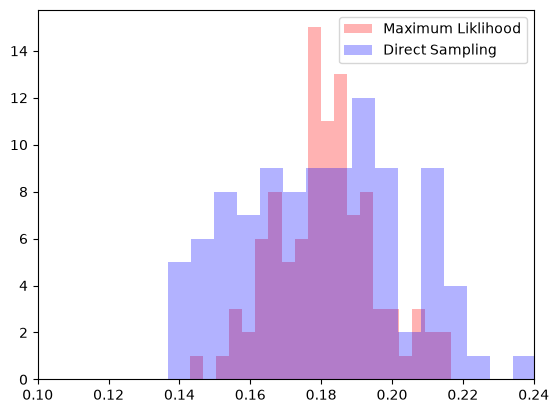

In [27]:
plt.figure()
plt.hist(ans_list, bins=20,alpha=0.3, color='r', label="Maximum Liklihood")
plt.hist(ans_list2, bins=20,alpha=0.3, color='b', label="Direct Sampling")

plt.xlim([0.1, 0.24])
plt.legend()
plt.show()


最尤推定を使った手法の方が、分散が小さい推定ができることが確認できます。
まとめると、量子位相推定を使わずに量子振幅推定によって数値積分を行うことができました。

最尤推定では、尤度関数を最大化するための計算量や、局所解の存在を考慮する必要があります。
上記の実装例では、optunaの試行回数n_trialsを減らすと、最尤推定が局所解に陥ってしまい、推定精度が大幅に悪化します。